<a href="https://colab.research.google.com/github/jhenningsen/Equity_Analysis/blob/main/HHM/HHM_volume_volatility.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
!pip install hmmlearn



In [48]:
import numpy as np
import pandas as pd
import yfinance as yf
from hmmlearn import hmm
import matplotlib.pyplot as plt

/tmp/ipykernel_6875/1600559210.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed

Fetching data for QQQ...


Training 2-State HMM on QQQ daily log returns, volume, and volatility...

STATE CHARACTERISTICS FOR QQQ

State 0:
  Expected Daily Log Return (Mean): 0.001430
  Expected Percent Return (Mean): 0.1431%
  Daily Volatility (Std Dev):     0.009976
  Expected Scaled Volume (Mean):  -0.452287
  Scaled Volume Std Dev:          0.616020
  Expected Scaled Volatility (Mean): -0.622982
  Scaled Volatility Std Dev:       0.332164
  Days spent in this state:       837 (56.2%)

State 1:
  Expected Daily Log Return (Mean): -0.000397
  Expected Percent Return (Mean): -0.0397%
  Daily Volatility (Std Dev):     0.021755
  Expected Scaled Volume (Mean):  0.590865
  Scaled Volume Std Dev:          1.090865
  Expected Scaled Volatility (Mean): 0.787939
  Scaled Volatility Std Dev:       1.006752
  Days spent in this state:       652 (43.8%)

Transition Probability Matrix (in %):
  From State 0: 98.85% 1.15% 
  From State 1: 1.46% 98.54% 


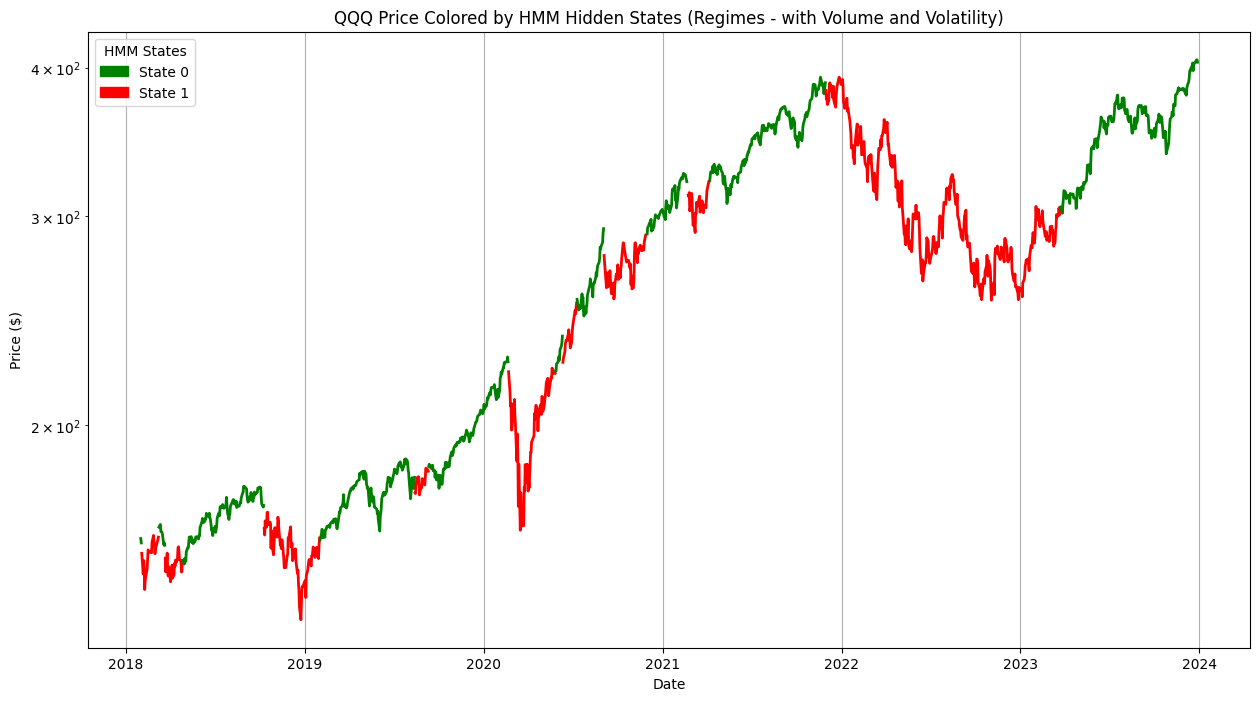

In [49]:
# ==========================================
# 1. CONFIGURATION & VARIABLE SETUP
# ==========================================
# Change this variable to "SPY", "IWM", or "QQQ"
TICKER = "QQQ"

START_DATE = "2018-01-01"
END_DATE = "2024-01-01"  # Adjust based on your preferred backtest window
N_STATES = 2

# ==========================================
# 2. DATA ACQUISITION & PREPROCESSING
# ==========================================
print(f"Fetching data for {TICKER}...")
df = yf.download(TICKER, start=START_DATE, end=END_DATE)

# Calculate Daily Log Returns
# log(Rt) = log(Pt / Pt-1)
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
df.dropna(inplace=True)

# Add Volume feature and standardize
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['Scaled_Volume'] = scaler.fit_transform(df[['Volume']])

# Add Volatility feature (rolling standard deviation of log returns) and standardize
ROLLING_WINDOW = 20 # 20 trading days for monthly volatility
df['Volatility'] = df['Log_Return'].rolling(window=ROLLING_WINDOW).std()
df.dropna(inplace=True)
# Use the same scaler to scale volatility
df['Scaled_Volatility'] = scaler.fit_transform(df[['Volatility']])

# Reshape data for hmmlearn (requires a 2D array: [samples, features])
# Now X will have three features: Log_Return, Scaled_Volume, and Scaled_Volatility
X = df[['Log_Return', 'Scaled_Volume', 'Scaled_Volatility']].values

# ==========================================
# 3. INITIALIZE AND FIT THE HMM
# ==========================================
# We use a Gaussian Emission HMM because log returns, volume, and volatility are continuous variables
model = hmm.GaussianHMM(
    n_components=N_STATES,
    covariance_type="full", # 'full' is appropriate for multiple features
    n_iter=1000,
    random_state=42
)

print(f"Training {N_STATES}-State HMM on {TICKER} daily log returns, volume, and volatility...") # Updated print statement
model.fit(X)

# Predict the hidden states for each day
hidden_states = model.predict(X)
df['State'] = hidden_states

# ==========================================
# 4. INTERPRET THE STATES
# ==========================================
print("\n" + "="*40)
print(f"STATE CHARACTERISTICS FOR {TICKER}")
print("="*40)

# Now model.means_ and model.covars_ will have dimensions corresponding to N_FEATURES (3 in this case)
for i in range(N_STATES):
    state_data = df[df['State'] == i]
    # Extract mean and variance for Log_Return, Scaled_Volume, and Scaled_Volatility
    log_return_mean = model.means_[i, 0] # First feature is Log_Return
    scaled_volume_mean = model.means_[i, 1] # Second feature is Scaled_Volume
    scaled_volatility_mean = model.means_[i, 2] # Third feature is Scaled_Volatility

    # For 'full' covariance, the diagonal elements give the variance of each feature
    # We need to extract the standard deviation for each feature from the covariance matrix
    log_return_std = np.sqrt(model.covars_[i, 0, 0])
    scaled_volume_std = np.sqrt(model.covars_[i, 1, 1])
    scaled_volatility_std = np.sqrt(model.covars_[i, 2, 2])

    # Convert log return mean to percent return mean
    percent_return_mean = (np.exp(log_return_mean) - 1) * 100

    print(f"\nState {i}:")
    print(f"  Expected Daily Log Return (Mean): {log_return_mean:.6f}")
    print(f"  Expected Percent Return (Mean): {percent_return_mean:.4f}%")
    print(f"  Daily Volatility (Std Dev):     {log_return_std:.6f}")
    print(f"  Expected Scaled Volume (Mean):  {scaled_volume_mean:.6f}")
    print(f"  Scaled Volume Std Dev:          {scaled_volume_std:.6f}")
    print(f"  Expected Scaled Volatility (Mean): {scaled_volatility_mean:.6f}")
    print(f"  Scaled Volatility Std Dev:       {scaled_volatility_std:.6f}")
    print(f"  Days spent in this state:       {len(state_data)} ({len(state_data)/len(df)*100:.1f}%)")

print("\nTransition Probability Matrix (in %):")
for i, row in enumerate(model.transmat_):
    print(f"  From State {i}: ", end="")
    for prob in row:
        print(f"{prob*100:.2f}% ", end="")
    print()

# ==========================================
# 5. VISUALIZATION
# ==========================================
# The visualization code remains mostly the same as it only plots the close price,
# but the states it represents are now influenced by volume.
plt.figure(figsize=(15, 8))
# Dynamically generate colors or provide enough for N_STATES
colors = ['green', 'red', 'blue', 'purple', 'orange', 'brown', 'pink', 'gray'] # Extended colors list
colors_map = {i: colors[i] for i in range(N_STATES)}

# Identify segments where the state is constant
# This creates a series that increments each time the state changes
state_segments = df['State'].diff().ne(0).cumsum()

# Plot each segment with its corresponding state color
for segment_id, segment_df in df.groupby(state_segments):
    state = segment_df['State'].iloc[0] # Get the state for this segment
    color = colors_map[state]
    plt.plot(segment_df.index, segment_df['Close'], color=color, linewidth=2) # Plot the segment as a line

plt.title(f"{TICKER} Price Colored by HMM Hidden States (Regimes - with Volume and Volatility)") # Updated title
plt.xlabel("Date")
plt.ylabel("Price ($)")

# Create a custom legend as plotting in a loop creates multiple labels
import matplotlib.patches as mpatches
legend_handles = [mpatches.Patch(color=colors_map[s], label=f'State {s}') for s in sorted(colors_map.keys())]
plt.legend(handles=legend_handles, title="HMM States")

plt.grid(True)
plt.yscale('log') # Useful for viewing multi-year index growth
plt.show()

## Applying the Trained HMM to New Data (Out-of-Sample Prediction)

Now, let's use the trained HMM to predict the hidden states for a period beyond our training data. We'll fetch new data and apply the model to it.

In [50]:
# Define the new date range for out-of-sample prediction
# 'END_DATE' from the original configuration is used as the START_DATE for this new period
PREDICTION_START_DATE = END_DATE
PREDICTION_END_DATE = pd.to_datetime('today').strftime('%Y-%m-%d')

print(f"Fetching new data for {TICKER} from {PREDICTION_START_DATE} to {PREDICTION_END_DATE}...")
df_new = yf.download(TICKER, start=PREDICTION_START_DATE, end=PREDICTION_END_DATE)

# Calculate Daily Log Returns for the new data
df_new['Log_Return'] = np.log(df_new['Close'] / df_new['Close'].shift(1))
df_new.dropna(inplace=True)

# Scale the new volume data using the *same scaler* fitted on the training data
df_new['Scaled_Volume'] = scaler.transform(df_new[['Volume']])

# Calculate Volatility for the new data and scale it using the *same scaler*
df_new['Volatility'] = df_new['Log_Return'].rolling(window=ROLLING_WINDOW).std()
df_new.dropna(inplace=True)
df_new['Scaled_Volatility'] = scaler.transform(df_new[['Volatility']])

# Reshape data for hmmlearn
X_new = df_new[['Log_Return', 'Scaled_Volume', 'Scaled_Volatility']].values

print(f"Predicting hidden states for {TICKER} on new data (with volume and volatility features)...")
hidden_states_new = model.predict(X_new)
df_new['State'] = hidden_states_new

display(df_new.head())

/tmp/ipykernel_6875/2625606667.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_new = yf.download(TICKER, start=PREDICTION_START_DATE, end=PREDICTION_END_DATE)
[*********************100%***********************]  1 of 1 completed

Fetching new data for QQQ from 2024-01-01 to 2026-06-08...
Predicting hidden states for QQQ on new data (with volume and volatility features)...


Price,Close,High,Low,Open,Volume,Log_Return,Scaled_Volume,Volatility,Scaled_Volatility,State
Ticker,QQQ,QQQ,QQQ,QQQ,QQQ,,,,,
Date,,,,,,,,,,
2024-01-31,411.895752,417.723947,411.717950,415.728540,64010600,-0.019780,8.498785e+09,0.009719,-0.578781,1
2024-02-01,416.745972,417.239887,412.725494,413.693579,51008600,0.011707,6.772490e+09,0.009502,-0.607686,1
2024-02-02,423.789246,425.004258,417.644938,418.642626,59602400,0.016759,7.913502e+09,0.009786,-0.569888,1
2024-02-05,423.236053,424.381910,419.828026,423.848504,39889200,-0.001306,5.296150e+09,0.009839,-0.562851,1
2024-02-06,422.386505,424.984505,420.045351,424.381912,35846100,-0.002009,4.759341e+09,0.009097,-0.661383,1


### Interpreting States for the New Data

Let's see how the market regimes (states) are distributed in this new period according to our trained HMM.

In [51]:
print("\n" + "="*40)
print(f"STATE CHARACTERISTICS FOR {TICKER} (NEW DATA - with Volume and Volatility)") # Updated title
print("="*40)

for i in range(N_STATES):
    state_data_new = df_new[df_new['State'] == i]
    if not state_data_new.empty:
        # Extract mean and variance for Log_Return, Scaled_Volume, and Scaled_Volatility from the model
        log_return_mean = model.means_[i, 0]
        scaled_volume_mean = model.means_[i, 1]
        scaled_volatility_mean = model.means_[i, 2]

        log_return_std = np.sqrt(model.covars_[i, 0, 0])
        scaled_volume_std = np.sqrt(model.covars_[i, 1, 1])
        scaled_volatility_std = np.sqrt(model.covars_[i, 2, 2])

        # Convert log return mean to percent return mean
        percent_return_mean = (np.exp(log_return_mean) - 1) * 100

        print(f"\nState {i}:")
        print(f"  Expected Daily Log Return (Mean - from model): {log_return_mean:.6f}")
        print(f"  Expected Percent Return (Mean - from model): {percent_return_mean:.4f}%")
        print(f"  Daily Volatility (Std Dev - from model):     {log_return_std:.6f}")
        print(f"  Expected Scaled Volume (Mean - from model):  {scaled_volume_mean:.6f}")
        print(f"  Scaled Volume Std Dev (from model):          {scaled_volume_std:.6f}")
        print(f"  Expected Scaled Volatility (Mean - from model): {scaled_volatility_mean:.6f}")
        print(f"  Scaled Volatility Std Dev (from model):       {scaled_volatility_std:.6f}")
        print(f"  Days spent in this state (new data):       {len(state_data_new)} ({len(state_data_new)/len(df_new)*100:.1f}%)")
    else:
        print(f"\nState {i}: Not observed in new data.")


STATE CHARACTERISTICS FOR QQQ (NEW DATA - with Volume and Volatility)

State 0: Not observed in new data.

State 1:
  Expected Daily Log Return (Mean - from model): -0.000397
  Expected Percent Return (Mean - from model): -0.0397%
  Daily Volatility (Std Dev - from model):     0.021755
  Expected Scaled Volume (Mean - from model):  0.590865
  Scaled Volume Std Dev (from model):          1.090865
  Expected Scaled Volatility (Mean - from model): 0.787939
  Scaled Volatility Std Dev (from model):       1.006752
  Days spent in this state (new data):       589 (100.0%)


### Visualization of New Data with Predicted States

Finally, let's visualize the price action of the new data, colored by the hidden states predicted by our HMM.

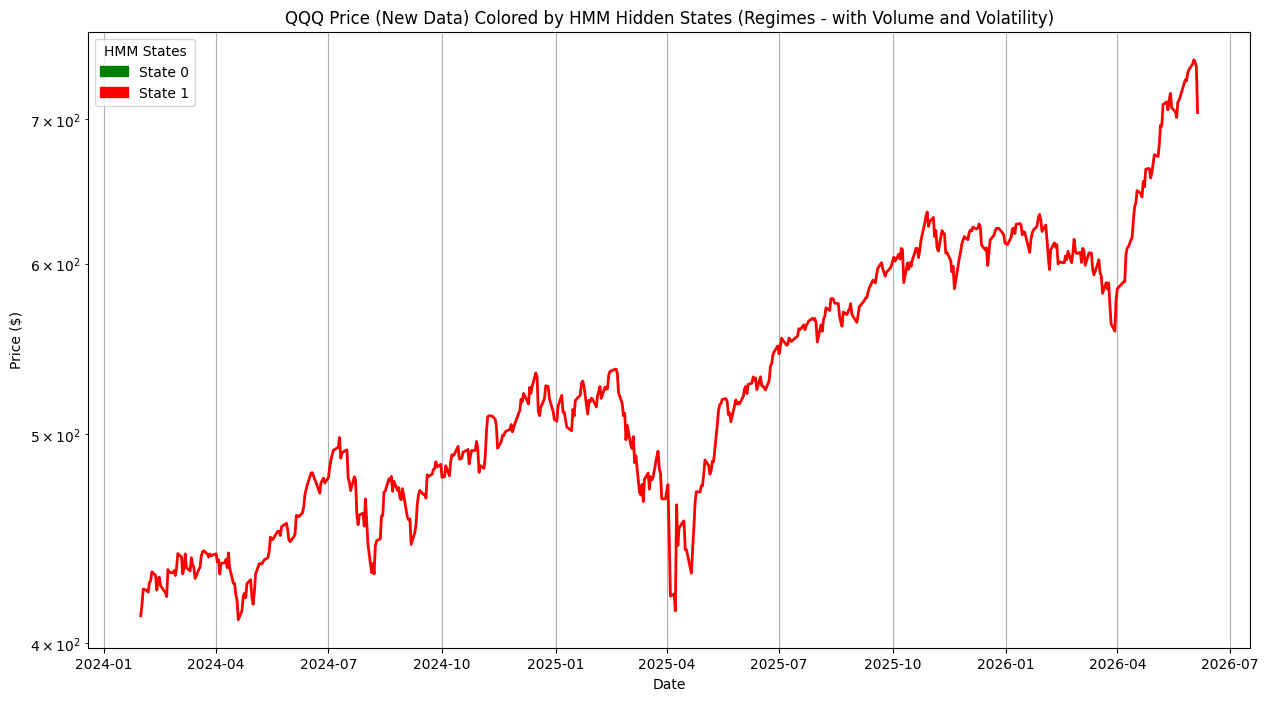

In [52]:
plt.figure(figsize=(15, 8))

# Reuse the colors_map created during the training phase
# colors_map = {i: colors[i] for i in range(N_STATES)} (already defined in previous cell)

# Identify segments where the state is constant for the new data
state_segments_new = df_new['State'].diff().ne(0).cumsum()

# Plot each segment with its corresponding state color
for segment_id, segment_df in df_new.groupby(state_segments_new):
    state = segment_df['State'].iloc[0] # Get the state for this segment
    color = colors_map[state]
    plt.plot(segment_df.index, segment_df['Close'], color=color, linewidth=2)

plt.title(f"{TICKER} Price (New Data) Colored by HMM Hidden States (Regimes - with Volume and Volatility)") # Updated title
plt.xlabel("Date")
plt.ylabel("Price ($)")

# Create a custom legend
legend_handles = [mpatches.Patch(color=colors_map[s], label=f'State {s}') for s in sorted(colors_map.keys())]
plt.legend(handles=legend_handles, title="HMM States")

plt.grid(True)
plt.yscale('log')
plt.show()